# Imports

In [9]:
import os, sys
import pandas as pd

# Setup path to project root
repo_root = r"C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)

from Tests.CPU.testing_helpers import (
    run_tests_pipeline,
    render_table2_accuracy,
    render_table2_runtime,
    run_and_plot_errors_vary_m,
    plot_convergence
)

from Tests.CPU.testing_helpers import (
    RADIAL_METHODS,
    run_NM_radial_sweep,
    run_bc_quad_radial_sweep,
    render_NM_radial_accuracy,
    render_NM_radial_runtime,
    render_bc_quad_radial_accuracy,
    render_bc_quad_radial_runtime,
    plot_radial_accuracy_vs_M,
    plot_radial_accuracy_vs_N,
    plot_radial_runtime_vs_M,
    plot_bc_quad_radial_accuracy,
    plot_bc_quad_comparison_vs_M,
    plot_convergence,
)

# Parameters

In [10]:
# ── Edit these freely ────────────────────────────────────────────────────────

N_VALS  = [32, 64, 128, 256, 512]   # angular point counts
M_VALS  = [32, 64, 128, 256, 512]   # radial  point counts
N_FIXED = 128                        # fixed N used in the BC/quad sweep

# Subset of RADIAL_METHODS to run (comment out any you want to skip)
ACTIVE_METHODS = RADIAL_METHODS      # all five by default

MUTE = False   # True = suppress per-case print output

In [11]:
# Run Tests

In [12]:
print("Running N × M sweep...")
df_nm = run_NM_radial_sweep(
    N_values=N_VALS,
    M_values=M_VALS,
    methods=ACTIVE_METHODS,
    bc_choice=1,    # Dirichlet
    quad_rule=1,    # Trapezoidal
    mute=MUTE,
)
print("Done.")

print(f"Running BC × quadrature sweep  (N = {N_FIXED})...")
df_bq = run_bc_quad_radial_sweep(
    N_fixed=N_FIXED,
    M_values=M_VALS,
    methods=ACTIVE_METHODS,
    mute=MUTE,
)
print("Done.")

Running N × M sweep...

── Uniform Radial ──
  N=  32, M=  32 | L2_rel=1.098e-05 | t=0.008s
  N=  32, M=  64 | L2_rel=2.661e-06 | t=0.057s


  N=  32, M= 128 | L2_rel=6.548e-07 | t=0.060s
  N=  32, M= 256 | L2_rel=1.624e-07 | t=0.014s
  N=  32, M= 512 | L2_rel=4.045e-08 | t=0.028s
  N=  64, M=  32 | L2_rel=1.098e-05 | t=0.016s
  N=  64, M=  64 | L2_rel=2.661e-06 | t=0.007s
  N=  64, M= 128 | L2_rel=6.548e-07 | t=0.012s
  N=  64, M= 256 | L2_rel=1.624e-07 | t=0.018s
  N=  64, M= 512 | L2_rel=4.045e-08 | t=0.049s
  N= 128, M=  32 | L2_rel=1.098e-05 | t=0.006s
  N= 128, M=  64 | L2_rel=2.661e-06 | t=0.020s
  N= 128, M= 128 | L2_rel=6.548e-07 | t=0.009s
  N= 128, M= 256 | L2_rel=1.624e-07 | t=0.043s
  N= 128, M= 512 | L2_rel=4.045e-08 | t=0.079s
  N= 256, M=  32 | L2_rel=1.098e-05 | t=0.010s
  N= 256, M=  64 | L2_rel=2.661e-06 | t=0.020s
  N= 256, M= 128 | L2_rel=6.548e-07 | t=0.027s
  N= 256, M= 256 | L2_rel=1.624e-07 | t=0.069s
  N= 256, M= 512 | L2_rel=4.045e-08 | t=0.166s
  N= 512, M=  32 | L2_rel=1.098e-05 | t=0.015s
  N= 512, M=  64 | L2_rel=2.661e-06 | t=0.030s
  N= 512, M= 128 | L2_rel=6.548e-07 | t=0.068s
  N= 512, M= 

# accuracy 

In [13]:
render_NM_radial_accuracy(df_nm)


render_bc_quad_radial_accuracy(df_bq)


Uniform Radial Accuracy


M,32,64,128,256,512
N,,,,,
32,1.10e-05,2.66e-06,6.55e-07,1.62e-07,4.04e-08
64,1.10e-05,2.66e-06,6.55e-07,1.62e-07,4.04e-08
128,1.10e-05,2.66e-06,6.55e-07,1.62e-07,4.04e-08
256,1.10e-05,2.66e-06,6.55e-07,1.62e-07,4.04e-08
512,1.10e-05,2.66e-06,6.55e-07,1.62e-07,4.04e-08



Nonuniform (sqrt) Accuracy


M,32,64,128,256,512
N,,,,,
32,5.10e-05,1.15e-05,2.71e-06,6.54e-07,1.60e-07
64,5.10e-05,1.15e-05,2.71e-06,6.54e-07,1.60e-07
128,5.10e-05,1.15e-05,2.71e-06,6.54e-07,1.60e-07
256,5.10e-05,1.15e-05,2.71e-06,6.54e-07,1.60e-07
512,5.10e-05,1.15e-05,2.71e-06,6.54e-07,1.60e-07



Nonuniform (rand) Accuracy


M,32,64,128,256,512
N,,,,,
32,4.94e-03,7.26e-04,1.40e-03,4.95e-04,1.06e-05
64,6.18e-04,1.63e-04,2.82e-05,2.30e-04,4.28e-04
128,5.24e-04,5.92e-04,6.40e-04,5.63e-05,2.49e-05
256,1.63e-04,5.34e-05,1.92e-04,5.08e-04,3.25e-04
512,1.82e-04,1.16e-03,3.03e-04,3.78e-04,4.13e-04



BC × Quad Accuracy Accuracy


# runtime

In [14]:
render_NM_radial_runtime(df_nm)


render_bc_quad_radial_runtime(df_bq)


Uniform Radial Runtime (s)


M,32,64,128,256,512
N,,,,,
32,0.0075,0.0571,0.0599,0.0135,0.0277
64,0.0162,0.0074,0.0118,0.0181,0.0492
128,0.0055,0.0197,0.0088,0.0430,0.0791
256,0.0102,0.0204,0.0268,0.0689,0.1661
512,0.0152,0.0297,0.0677,0.1757,0.3273



Nonuniform (sqrt) Runtime (s)


M,32,64,128,256,512
N,,,,,
32,0.0044,0.0058,0.0073,0.0115,0.0100
64,0.0040,0.0072,0.0239,0.0162,0.0298
128,0.0061,0.0134,0.0153,0.0353,0.0598
256,0.0073,0.0155,0.0221,0.0638,0.1448
512,0.0098,0.0265,0.0668,0.1285,0.2486



Nonuniform (rand) Runtime (s)


M,32,64,128,256,512
N,,,,,
32,0.0046,0.0047,0.0077,0.0076,0.0125
64,0.0038,0.0137,0.0069,0.0119,0.0251
128,0.0037,0.0130,0.0167,0.0267,0.0656
256,0.0110,0.0139,0.0225,0.0648,0.1234
512,0.0128,0.0298,0.0713,0.1348,0.2466



BC × Quad Runtime Runtime (s)


# Accuracy Plots

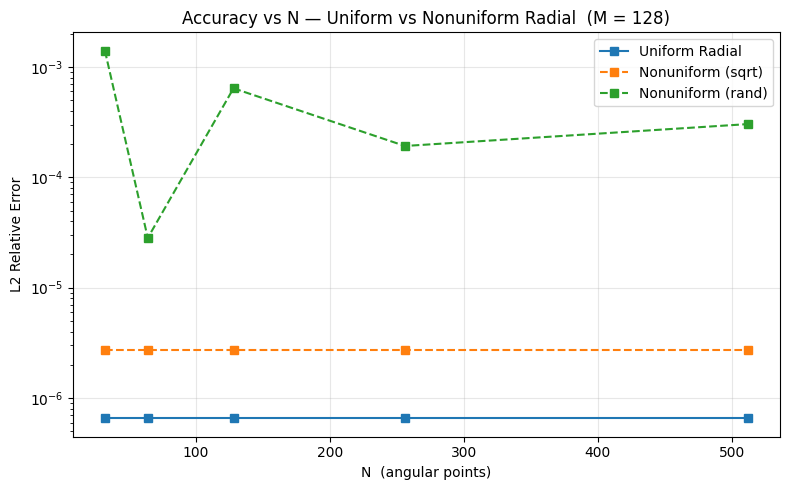

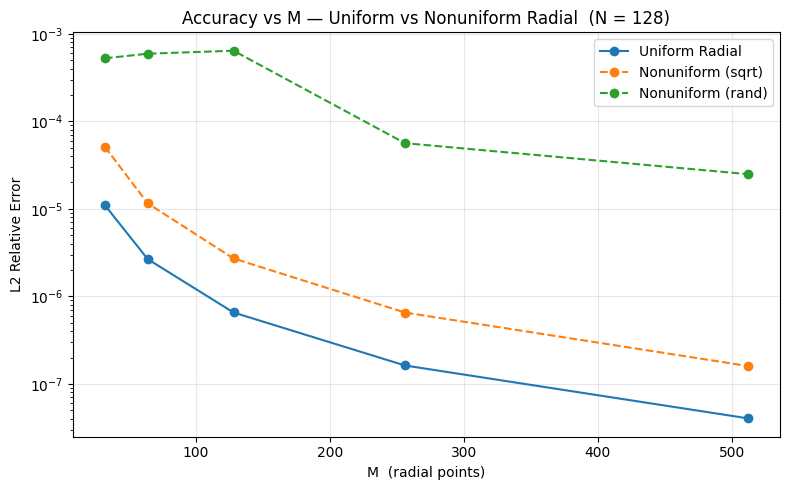

In [15]:
plot_radial_accuracy_vs_N(df_nm, M_fixed=M_VALS[len(M_VALS)//2])

plot_radial_accuracy_vs_M(df_nm, N_fixed=N_VALS[len(N_VALS)//2])


# Runtime Plots

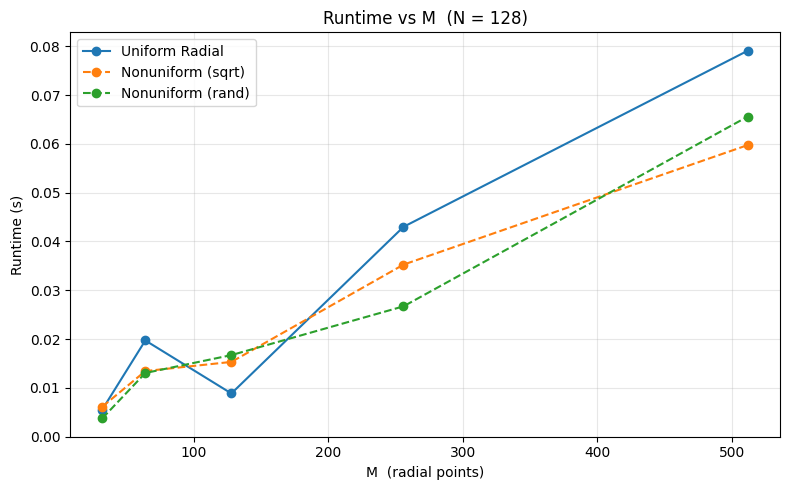

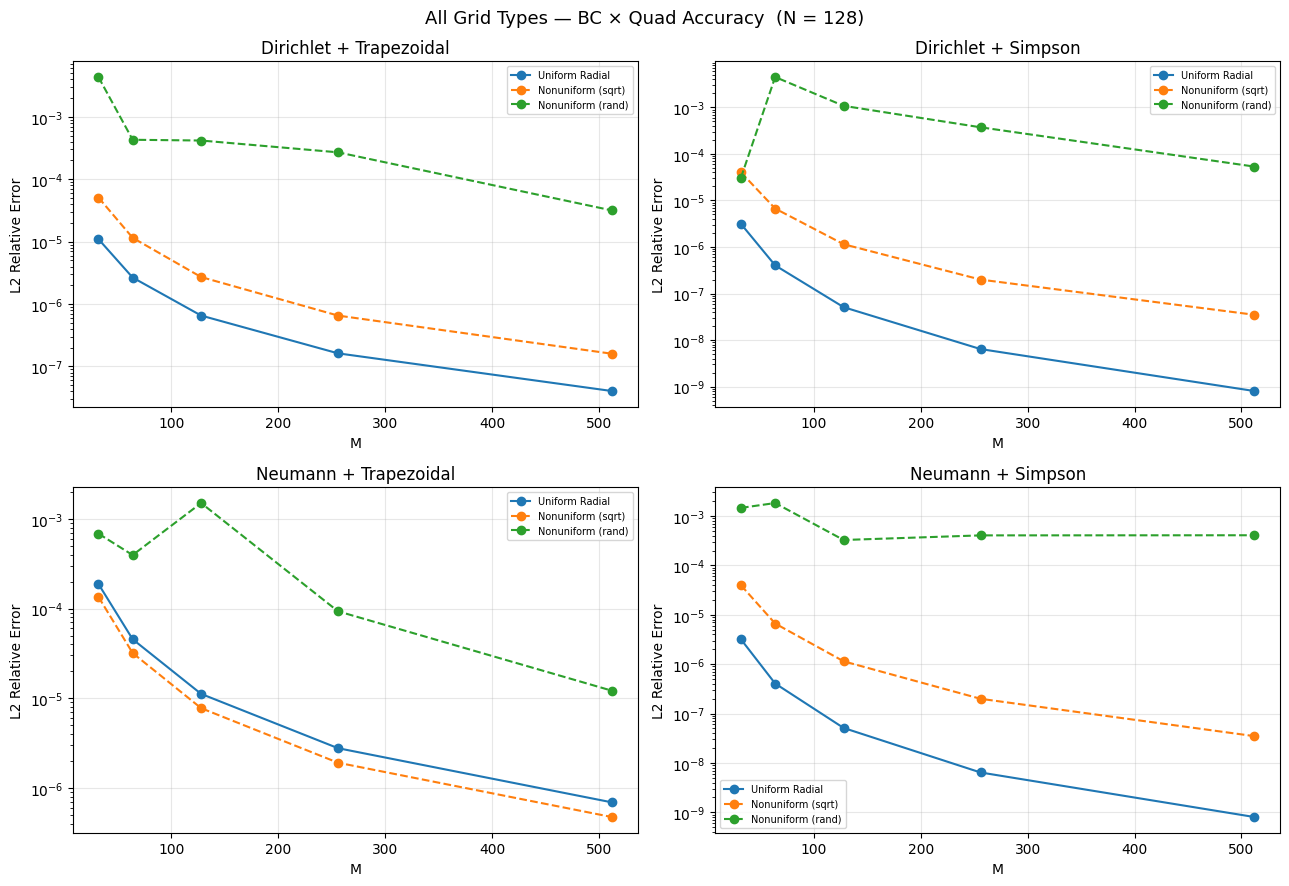

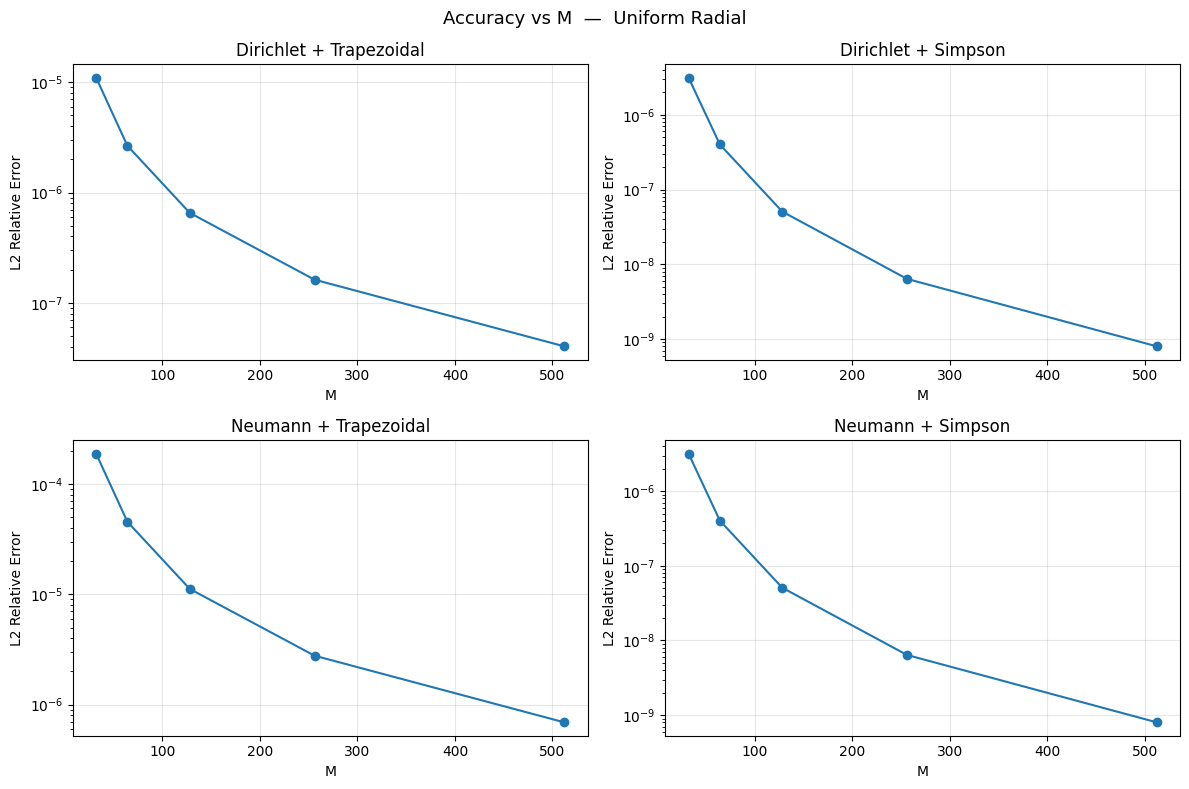

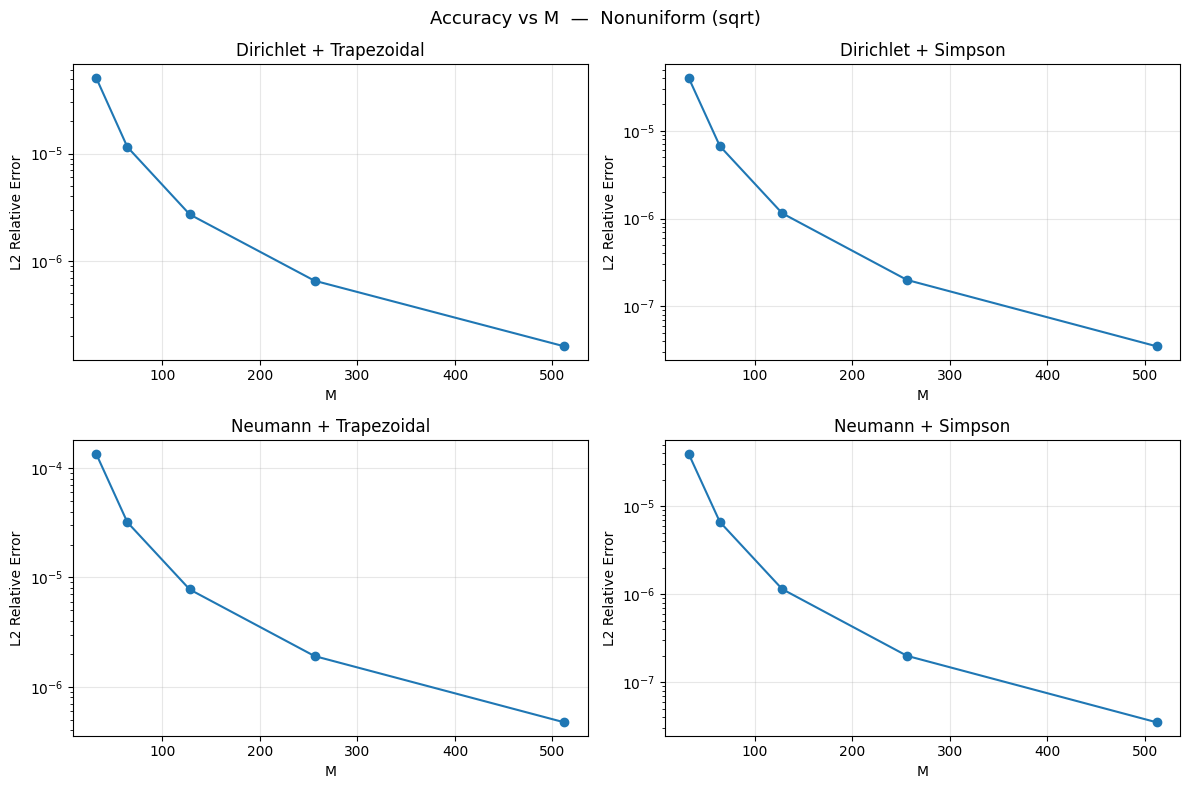

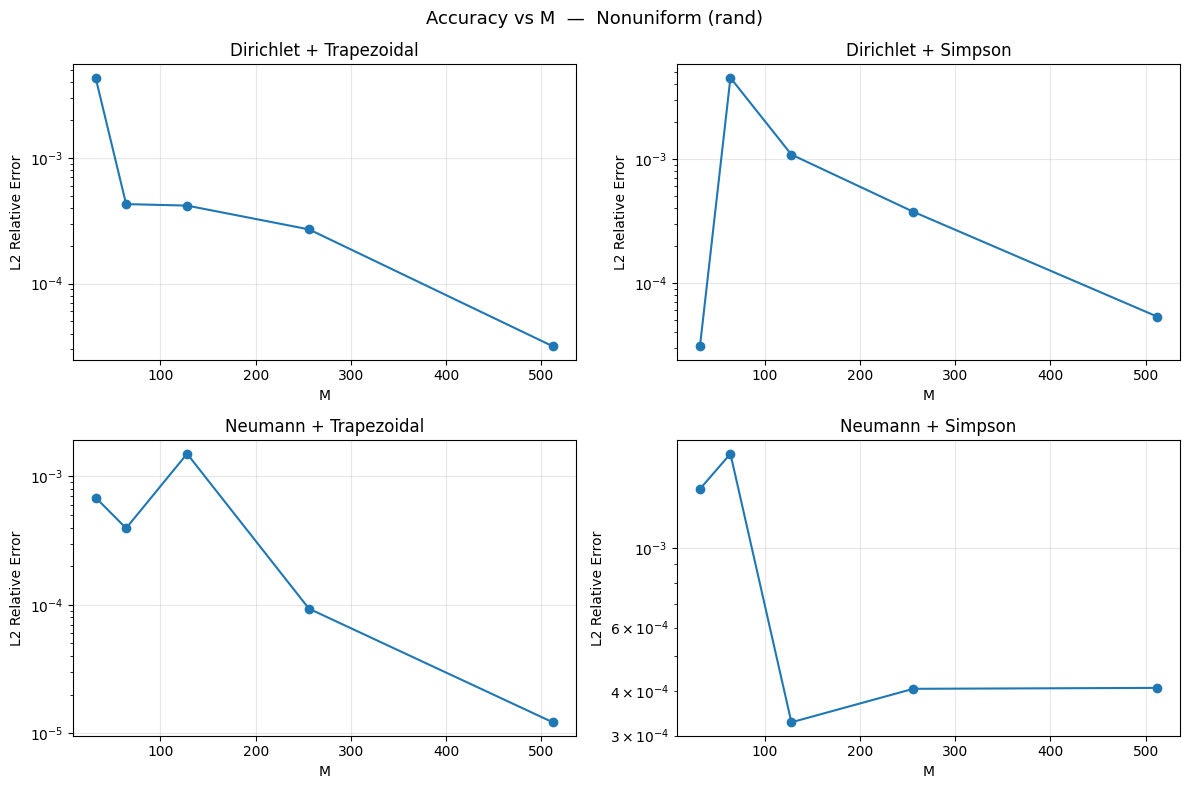

In [16]:
plot_radial_runtime_vs_M(df_nm, N_fixed=N_VALS[len(N_VALS)//2])

plot_bc_quad_comparison_vs_M(df_bq, N_fixed=N_FIXED)


for method in ACTIVE_METHODS:
    plot_bc_quad_radial_accuracy(df_bq, method["label"])